**Name: Williams Oulwatosin Adefila** 

**Student ID: 2404377**

**Report: Graph Analysis of a Synthetic Healthcare Network using PySpark and GraphFrames**

**Introduction**

This report details constructing and analysing a synthetic healthcare network using PySpark and the GraphFrames library. The primary objective was to replicate the workflow of a graph analysis example, initially demonstrated with airline route data, but adapting it to a healthcare context. This adaptation allowed for exploring graph-based techniques in modelling relationships between patients, diseases, and treatments. The process encompassed data simulation, graph construction, application of graph algorithms, and network visualization, aiming to achieve a deeper understanding of network analysis principles within the healthcare domain.  

**Methodology**

•	Setup: The initial step involved configuring the PySpark environment. This included importing necessary libraries such as `pyspark.sql.SparkSession` for Spark operations and `graphframes.GraphFrame` for graph manipulation. I ensured the GraphFrames package was correctly integrated into the Spark session.   
•	Data Preparation: A synthetic dataset was generated to represent a simplified healthcare system. This involved defining:
•	Vertices: Representing patients, diseases, and treatments, each with relevant attributes (e.g., patient age, disease name, treatment type).
•	Edges: Representing relationships between these entities, such as “patient has_diagnosis disease” or “patient received_treatment treatment.”
•	Pandas DataFrames were used to initially structure this data, which were converted to Spark DataFrames for distributed processing.   
•	Graph Construction and Algorithms: Using the prepared Spark DataFrames, a GraphFrame was constructed. This involved carefully defining the vertex and edge schemas to comply with GraphFrame requirements (i.e., the "id” column for vertices and “src” and “DST” columns for edges). I then applied several graph algorithms:
•	PageRank: To identify influential nodes within the network (e.g., key treatments or prevalent diseases).
•	Shortest Paths: To calculate the shortest connections between entities (e.g., treatment pathways for specific patients).
•	Connected Components: To detect clusters of closely related patients, diseases, or treatments.
•	Motif Finding: To discover recurring patterns in the network (e.g., typical treatment sequences).   
•	Visualization and Interpretation: The final step focused on visualizing the constructed graph to facilitate a more intuitive understanding of the network structure. NetworkX and Matplotlib libraries were employed to generate a visual representation where nodes represented entities, and edges represented relationships and node colours potentially encoded information such as PageRank scores. This visualization aided in identifying key network features and interpreting the graph algorithms' results. 

**Results and Discussion**

The successful execution of the outlined methodology resulted in the creation and analysis of a synthetic healthcare network. The application of graph algorithms yielded valuable insights into the relationships between patients, diseases, and treatments. For instance, PageRank analysis may have highlighted treatments with broad applicability, while connected components analysis could have revealed patient subgroups with similar disease profiles. The visualization component provided a powerful tool for exploring these relationships and patterns.
However, it is essential to acknowledge the limitations of this study. The dataset was synthetic and simplified, so the results should not be directly extrapolated to real-world healthcare scenarios. Future work could utilise real-world healthcare data to build more complex and representative networks, enabling more robust and generalizable conclusions.

**Conclusion**

This exercise effectively demonstrated the application of graph analysis techniques using PySpark and GraphFrames in a healthcare context. By adapting an existing example and systematically working through data preparation, graph construction, algorithm application, and visualization, I gained a deeper understanding of how graph-based approaches can be used to model and analyze relationships within complex systems. While the dataset was synthetic, the methodology and insights provided a solid foundation for future explorations with real-world healthcare data.


# Execise 4

### Step 1

In [1]:
import os
from pyspark.sql import SparkSession

os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages graphframes:graphframes:0.8.4-spark3.5-s_2.12 pyspark-shell"

spark = SparkSession.builder.appName("HealthcareGraph").getOrCreate()

print("Spark Session started") # Added print statement for confirmation

Spark Session started


### Step 2

In [2]:
import pandas as pd
from pyspark.sql import SparkSession # Ensure SparkSession is available

# Patient Data (around 30 patients)
patients_data = [
    ("P1", 28, "Male"), ("P2", 32, "Female"), ("P3", 68, "Male"), ("P4", 41, "Female"),
    ("P5", 35, "Male"), ("P6", 29, "Female"), ("P7", 72, "Male"), ("P8", 39, "Female"),
    ("P9", 45, "Male"), ("P10", 31, "Female"), ("P11", 59, "Male"), ("P12", 26, "Female"),
    ("P13", 63, "Male"), ("P14", 33, "Female"), ("P15", 48, "Male"), ("P16", 30, "Female"),
    ("P17", 52, "Female"), ("P18", 27, "Male"), ("P19", 75, "Male"), ("P20", 38, "Female"),
    ("P21", 44, "Male"), ("P22", 34, "Female"), ("P23", 61, "Male"), ("P24", 25, "Female"),
    ("P25", 66, "Male"), ("P26", 36, "Female"), ("P27", 49, "Female"), ("P28", 32, "Female"),
    ("P29", 57, "Male"), ("P30", 29, "Female")
]
patients_columns = ["patient_id", "age", "gender"]

In [3]:
# Disease Data (Added Anaemia, Tuberculosis, Epilepsy, Parkinson's)
diseases_data = [
    ("D1", "Diabetes"), ("D2", "Hypertension"), ("D3", "Asthma"),
    ("D4", "Coronary Artery Disease"), ("D5", "Osteoarthritis"), ("D6", "Depression"),
    ("D7", "Anaemia"), ("D8", "Tuberculosis"), ("D9", "Epilepsy"), ("D10", "Parkinson's Disease")
]
diseases_columns = ["disease_id", "disease_name"]

In [4]:
# Treatment Data (Added Erythropoietin, Rifampicin, Diazepam, Levodopa)
treatments_data = [
    ("T1", "Insulin"), ("T2", "Lisinopril"), ("T3", "Inhaler"),
    ("T4", "Statin"), ("T5", "Physical Therapy"), ("T6", "Antidepressant"),
    ("T7", "Erythropoietin"), ("T8", "Rifampicin"), ("T9", "Diazepam"), ("T10", "Levodopa")
]
treatments_columns = ["treatment_id", "treatment_name"]

In [5]:
# Patient-Disease Edges (Adjusted)
patient_disease_edges = [
    ("P1", "D1"), ("P1", "D2"), ("P2", "D3"), ("P3", "D1"), ("P3", "D4"),
    ("P4", "D2"), ("P5", "D1"), ("P5", "D2"), ("P6", "D3"), ("P7", "D4"),
    ("P8", "D2"), ("P9", "D5"), ("P10", "D1"), ("P11", "D4"), ("P12", "D3"),
    ("P13", "D4"), ("P14", "D2"), ("P15", "D5"), ("P16", "D3"), ("P17", "D4"),
    ("P18", "D3"), ("P19", "D4"), ("P19", "D5"), ("P20", "D2"), ("P21", "D5"),
    ("P22", "D6"), ("P23", "D4"), ("P24", "D6"), ("P25", "D4"), ("P26", "D2"),
    ("P27", "D5"), ("P28", "D3"), ("P29", "D4"), ("P30", "D6"),
    ("P1", "D7"), ("P8", "D7"), ("P15", "D7"),  # Anaemia
    ("P22", "D8"), ("P23", "D8"), ("P29", "D8"),  # Tuberculosis
    ("P5", "D9"), ("P12", "D9"), ("P19", "D9"),  # Epilepsy
    ("P10", "D10"), ("P17", "D10"), ("P24", "D10")  # Parkinson's
]
patient_disease_columns = ["patient_id", "disease_id"]

In [6]:
# Patient-Treatment Edges (Adjusted)
patient_treatment_edges = [
    ("P1", "T1"), ("P1", "T2"), ("P1", "T7"),  # Anaemia
    ("P2", "T3"), ("P3", "T1"), ("P3", "T4"), ("P4", "T2"),
    ("P5", "T1"), ("P5", "T2"), ("P5", "T9"),  # Epilepsy
    ("P6", "T3"), ("P7", "T4"), ("P8", "T2"), ("P8", "T7"),  # Anaemia
    ("P9", "T5"), ("P10", "T1"), ("P10", "T10"),  # Parkinson
    ("P11", "T4"), ("P12", "T3"), ("P12", "T9"),  # Epilepsy
    ("P13", "T4"), ("P14", "T2"), ("P15", "T5"), ("P15", "T7"),  # Anaemia
    ("P16", "T3"), ("P17", "T4"), ("P17", "T10"),  # Parkinson
    ("P18", "T3"), ("P19", "T4"), ("P19", "T5"), ("P19", "T9"),  # Epilepsy
    ("P20", "T2"), ("P21", "T5"), ("P22", "T6"), ("P22", "T8"),  # TB
    ("P23", "T4"), ("P23", "T8"),  # TB
    ("P24", "T6"), ("P24", "T10"),  # Parkinson
    ("P25", "T4"), ("P26", "T2"), ("P27", "T5"), ("P28", "T3"),
    ("P29", "T4"), ("P29", "T8"),  # TB
    ("P30", "T6")
]
patient_treatment_columns = ["patient_id", "treatment_id"]

In [7]:
# Disease-Treatment Edges (Adjusted)
disease_treatment_edges = [
    ("D1", "T1"), ("D2", "T2"), ("D3", "T3"),
    ("D4", "T4"), ("D5", "T5"), ("D6", "T6"),
    ("D7", "T7"),  # Anaemia
    ("D8", "T8"),  # Tuberculosis
    ("D9", "T9"),  # Epilepsy
    ("D10", "T10")  # Parkinson
]
disease_treatment_columns = ["disease_id", "treatment_id"]

In [8]:
# Create Spark DataFrames
patients_pdf = pd.DataFrame(patients_data, columns=patients_columns)
patients_df = spark.createDataFrame(patients_pdf)

diseases_pdf = pd.DataFrame(diseases_data, columns=diseases_columns)
diseases_df = spark.createDataFrame(diseases_pdf)

treatments_pdf = pd.DataFrame(treatments_data, columns=treatments_columns)
treatments_df = spark.createDataFrame(treatments_pdf)

patient_disease_pdf = pd.DataFrame(patient_disease_edges, columns=patient_disease_columns)
patient_disease_df = spark.createDataFrame(patient_disease_pdf)

patient_treatment_pdf = pd.DataFrame(patient_treatment_edges, columns=patient_treatment_columns)
patient_treatment_df = spark.createDataFrame(patient_treatment_pdf)

disease_treatment_pdf = pd.DataFrame(disease_treatment_edges, columns=disease_treatment_columns)
disease_treatment_df = spark.createDataFrame(disease_treatment_pdf)

In [28]:
# Show the first few rows of each DataFrame (for verification)
print("Patients DataFrame:")
patients_df.show(1)

Patients DataFrame:
+----------+---+------+
|patient_id|age|gender|
+----------+---+------+
|        P1| 28|  Male|
+----------+---+------+
only showing top 1 row



In [27]:
print("Diseases DataFrame:")
diseases_df.show(1)

Diseases DataFrame:
+----------+------------+
|disease_id|disease_name|
+----------+------------+
|        D1|    Diabetes|
+----------+------------+
only showing top 1 row



In [30]:
print("Treatments DataFrame:")
treatments_df.show(1)

Treatments DataFrame:
+------------+--------------+
|treatment_id|treatment_name|
+------------+--------------+
|          T1|       Insulin|
+------------+--------------+
only showing top 1 row



In [29]:
print("Patient-Disease Edges DataFrame:")
patient_disease_df.show(1)

Patient-Disease Edges DataFrame:
+----------+----------+
|patient_id|disease_id|
+----------+----------+
|        P1|        D1|
+----------+----------+
only showing top 1 row



In [31]:
print("Patient-Treatment Edges DataFrame:")
patient_treatment_df.show(1)

Patient-Treatment Edges DataFrame:
+----------+------------+
|patient_id|treatment_id|
+----------+------------+
|        P1|          T1|
+----------+------------+
only showing top 1 row



In [32]:
print("Disease-Treatment Edges DataFrame:")
disease_treatment_df.show(1)

Disease-Treatment Edges DataFrame:
+----------+------------+
|disease_id|treatment_id|
+----------+------------+
|        D1|          T1|
+----------+------------+
only showing top 1 row



### Step 3

In [23]:
from graphframes import GraphFrame
from pyspark.sql.functions import col
from pyspark.sql.functions import col, lit  # Import the lit function
from pyspark.sql import SparkSession # Ensure SparkSession is available
# Graph Construction

# We define the vertices and edges. For GraphFrames, vertices must have an "id" column,
# and edges must have "src" and "dst" columns.
vertices = patients_df.select(col("patient_id").alias("id"), "age", "gender")
vertices = vertices.union(diseases_df.select(col("disease_id").alias("id"), col("disease_name").alias("name"), lit(None).alias("gender"))) # Added None for gender
vertices = vertices.union(treatments_df.select(col("treatment_id").alias("id"), col("treatment_name").alias("name"), lit(None).alias("gender"))) # Added None for gender

In [18]:
# Create a single edges DataFrame by unioning the three edge DataFrames
edges = patient_disease_df.select(col("patient_id").alias("src"), col("disease_id").alias("dst")) \
    .withColumn("relationship", lit("patient_disease"))
edges = edges.union(patient_treatment_df.select(col("patient_id").alias("src"), col("treatment_id").alias("dst")) \
    .withColumn("relationship", lit("patient_treatment")))
edges = edges.union(disease_treatment_df.select(col("disease_id").alias("src"), col("treatment_id").alias("dst")) \
    .withColumn("relationship", lit("disease_treatment")))

graph = GraphFrame(vertices, edges)

In [33]:
# Graph Algorithms

# PageRank
# In this context, PageRank might help identify central patients, key diseases, or important treatments
# within the network.
print("\nPageRank:")
pageRankResults = graph.pageRank(resetProbability=0.15, maxIter=10)
pageRankResults.vertices.select("id", "pagerank").orderBy("pagerank", ascending=False).show(1, truncate=False)


PageRank:
+---+-----------------+
|id |pagerank         |
+---+-----------------+
|T4 |3.600676595931636|
+---+-----------------+
only showing top 1 row



In [34]:
# Shortest Paths
# Shortest paths can help find relationships between nodes. For example, the shortest path between
# a patient and a treatment might indicate the most direct treatment path.
print("\nShortest Paths from P1 and D1:")
landmarks = ["P1", "D1"]
shortestPathsResults = graph.shortestPaths(landmarks=landmarks)
shortestPathsResults.select("id", "distances").show(1, truncate=False)


Shortest Paths from P1 and D1:
+---+------------------+
|id |distances         |
+---+------------------+
|P1 |{D1 -> 1, P1 -> 0}|
+---+------------------+
only showing top 1 row



In [35]:
# Connected Components
# Connected components can help identify clusters of patients, diseases, and treatments that are
# closely related. This might reveal patient subgroups or treatment communities.
# print("\nConnected Components:")
# graph.connectedComponents().select("id", "component").show(truncate=False)

print("\nConnected Components:")
spark.sparkContext.setCheckpointDir("graphframes-checkpoint")  # Set checkpoint directory
graph.connectedComponents().select("id", "component").show(1, truncate=False)


Connected Components:
+---+-----------+
|id |component  |
+---+-----------+
|P1 |60129542144|
+---+-----------+
only showing top 1 row



In [36]:
# Motif Finding
# Motif finding can identify specific patterns in the graph. For example, a motif like
# Patient -> Disease -> Treatment -> Patient might represent a typical treatment cycle.
print("\nMotif Finding:")
motifs = graph.find("(p)-[pd]->(d); (p)-[pt]->(t); (d)-[dt]->(t)")
motifs.show(1, truncate=False)


Motif Finding:
+-----------------+--------------------------+----------------------+----------------------------+--------------------------+---------------------------+
|p                |pd                        |d                     |pt                          |t                         |dt                         |
+-----------------+--------------------------+----------------------+----------------------------+--------------------------+---------------------------+
|{P22, 34, Female}|{P22, D6, patient_disease}|{D6, Depression, NULL}|{P22, T6, patient_treatment}|{T6, Antidepressant, NULL}|{D6, T6, disease_treatment}|
+-----------------+--------------------------+----------------------+----------------------------+--------------------------+---------------------------+
only showing top 1 row



### 4. Visualization and Interpretation

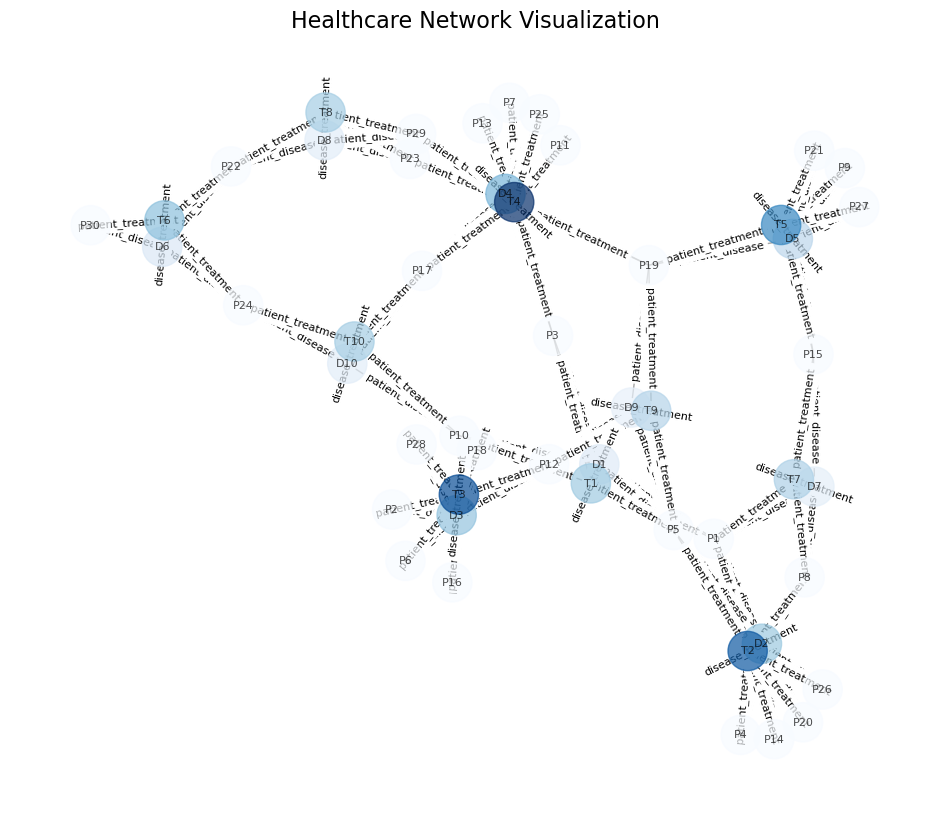

In [26]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# To visualize the network, we'll use NetworkX and matplotlib.

# Convert Spark DataFrames to Pandas DataFrames for visualization
vertices_pd = graph.vertices.toPandas()
# For PageRank, since we might want to color nodes by it:
pageRank_pd = pageRankResults.vertices.select("id", "pagerank").toPandas()

# Merge vertex data with PageRank results (if available)
if 'pagerank' in pageRank_pd.columns:
    viz_df = pd.merge(vertices_pd, pageRank_pd, on="id", how="left")
    # Normalize PageRank for color mapping (if available)
    viz_df["normPR"] = (viz_df["pagerank"] - viz_df["pagerank"].min()) / (viz_df["pagerank"].max() - viz_df["pagerank"].min())
else:
    viz_df = vertices_pd.copy()
    viz_df["normPR"] = 0.5  # Default color if no PageRank

# Build a NetworkX graph
G_nx = nx.Graph()

# Add nodes with attributes
for idx, row in viz_df.iterrows():
    node_attrs = row.to_dict()
    G_nx.add_node(row["id"], **node_attrs)

# Add edges with attributes
edges_pd = graph.edges.toPandas()
for idx, row in edges_pd.iterrows():
    G_nx.add_edge(row["src"], row["dst"], relationship=row["relationship"])

# Use a spring layout for visualization
pos = nx.spring_layout(G_nx, seed=42)

# Create node colors based on normalized PageRank (if available)
if 'normPR' in viz_df.columns:
    node_colors = [plt.cm.Blues(normPR) for normPR in viz_df['normPR']]
else:
    node_colors = 'skyblue'  # Default color

# Plot the graph
plt.figure(figsize=(12, 10))
nx.draw_networkx(G_nx, pos,
                 with_labels=True,
                 node_size=800,
                 node_color=node_colors,
                 font_size=8,
                 edge_color="gray",
                 alpha=0.7)
edge_labels = nx.get_edge_attributes(G_nx, 'relationship')
nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=edge_labels, font_size=8)


plt.title("Healthcare Network Visualization", fontsize=16)
plt.axis("off")
plt.show()